In [3]:
import pandas as pd
import numpy as np

In [4]:
data = 'wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
!wget $data

--2026-10-05 13:41:10--  http://wget/
Resolving wget (wget)... failed: Name or service not known.
wget: unable to resolve host address ‘wget’
--2026-10-05 13:41:10--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.6’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.06s   

2026-10-05 13:41:10 (10.2 MB/s) - ‘car_fuel_efficiency_2026.csv.6’ saved [635180/635180]

FINISHED --2026-10-05 13:41:10--
Total wall clock time: 0.6s
Downloaded: 1 files, 620K in 0.06s (10.2 MB/s)


In [5]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [6]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [7]:
df.columns.str.lower()

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [8]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]

In [9]:
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


In [10]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


In [11]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [12]:
df.dtypes == 'str'

engine_displacement    False
horsepower             False
vehicle_weight         False
model_year             False
fuel_efficiency_mpg    False
dtype: bool

In [13]:
df.dtypes[df.dtypes == 'str']

Series([], dtype: object)

In [14]:
df.dtypes[df.dtypes == 'str'].index

Index([], dtype='str')

In [15]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

[]

In [16]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')
    df[col] = df[col].str.lower().str.replace('-', '_')

In [17]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


In [18]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [19]:
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


In [20]:
for col in df.columns:
    print(col)
    print(df[col].head())
    print()

engine_displacement
0    2180
1    2390
2    2320
3    2130
4    2580
Name: engine_displacement, dtype: int64

horsepower
0    243.0
1    272.0
2    267.0
3    258.0
4    304.0
Name: horsepower, dtype: float64

vehicle_weight
0    3870
1    4210
2    4240
3    4490
4    4510
Name: vehicle_weight, dtype: int64

model_year
0    2006
1    2008
2    1996
3    1989
4    1994
Name: model_year, dtype: int64

fuel_efficiency_mpg
0    31.9
1    31.3
2    27.5
3    28.5
4    31.0
Name: fuel_efficiency_mpg, dtype: float64



In [21]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

engine_displacement
[2180 2390 2320 2130 2580]
127

horsepower
[243. 272. 267. 258. 304.]
153

vehicle_weight
[3870 4210 4240 4490 4510]
176

model_year
[2006 2008 1996 1989 1994]
50

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

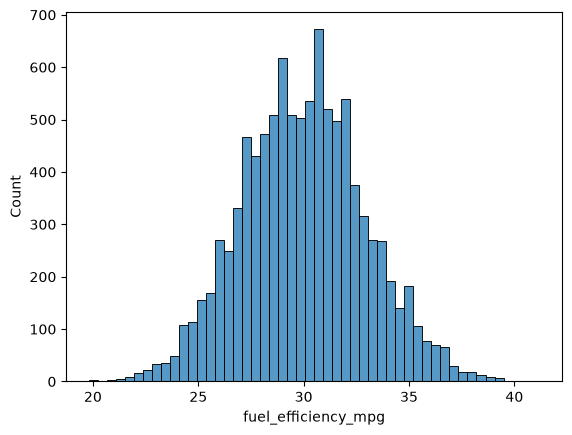

In [23]:
sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg < 100000], bins = 50)

In [24]:
df.isnull()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
9995,False,False,False,False,False
9996,False,False,False,False,False
9997,False,False,False,False,False
9998,False,False,False,False,False


In [25]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [31]:
df['horsepower'].median()

np.float64(254.0)

In [41]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [42]:
df_train['horsepower'].mean()

np.float64(254.46338337605272)

In [44]:
print("n_train =", n_train)
print("n_val   =", n_val)
print("n_test  =", n_test)

n_train = 6000
n_val   = 2000
n_test  = 2000


In [45]:
df_train['horsepower'].mean()

np.float64(254.46338337605272)

In [47]:
df_train_0 = df_train.copy()
df_val_0 = df_val.copy()

df_train_0['horsepower'] = df_train_0['horsepower'].fillna(0)
df_val_0['horsepower'] = df_val_0['horsepower'].fillna(0)

In [48]:
def train_linear_regression(X, y):
    X = np.column_stack([np.ones(X.shape[0]), X])
    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return w

In [49]:
X_train = df_train_0.drop(columns=['fuel_efficiency_mpg']).values
y_train = df_train_0['fuel_efficiency_mpg'].values

X_val = df_val_0.drop(columns=['fuel_efficiency_mpg']).values
y_val = df_val_0['fuel_efficiency_mpg'].values

w = train_linear_regression(X_train, y_train)

X_val_with_ones = np.column_stack([np.ones(X_val.shape[0]), X_val])
y_pred = X_val_with_ones @ w

In [50]:
rmse = np.sqrt(np.mean((y_val - y_pred) ** 2))
round(rmse, 3)

np.float64(2.205)

In [53]:
df_train_mean = df_train.copy()
df_val_mean = df_val.copy()

mean_hp = df_train['horsepower'].mean()

df_train_mean['horsepower'] = df_train_mean['horsepower'].fillna(mean_hp)
df_val_mean['horsepower'] = df_val_mean['horsepower'].fillna(mean_hp)

print("Training horsepower mean:", mean_hp)

Training horsepower mean: 254.46338337605272


In [54]:
print("Training horsepower mean:", mean_hp)

print("Missing values in training:", df_train_mean['horsepower'].isnull().sum())
print("Missing values in validation:", df_val_mean['horsepower'].isnull().sum())

Training horsepower mean: 254.46338337605272
Missing values in training: 0
Missing values in validation: 0


In [56]:
def train_linear_regression(X, y):
    X = np.column_stack([np.ones(X.shape[0]), X])
    
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y
    
    return w

In [57]:
X_train = df_train_mean.drop(columns=['fuel_efficiency_mpg']).values
y_train = df_train_mean['fuel_efficiency_mpg'].values

X_val = df_val_mean.drop(columns=['fuel_efficiency_mpg']).values
y_val = df_val_mean['fuel_efficiency_mpg'].values

In [59]:
w = train_linear_regression(X_train, y_train)
w

array([-1.53296456e+02, -1.02385641e-03, -6.48621548e-03, -3.88827684e-03,
        1.01978967e-01])

In [60]:
X_val_with_ones = np.column_stack([np.ones(X_val.shape[0]), X_val])

y_pred = X_val_with_ones @ w

In [61]:
y_pred[:10]

array([31.54288381, 29.92505122, 31.56459523, 29.95461814, 31.00171448,
       27.96175682, 29.23542633, 27.27075441, 29.57196005, 29.41155911])

In [62]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = np.mean(error ** 2)
    return np.sqrt(mse)

In [63]:
rmse(y_val, y_pred)

np.float64(2.201817484568825)

In [64]:
df_train_zero = df_train.copy()
df_val_zero = df_val.copy()

In [65]:
df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)

In [66]:
X_train_zero = df_train_zero.drop(columns=['fuel_efficiency_mpg']).values
y_train_zero = df_train_zero['fuel_efficiency_mpg'].values

X_val_zero = df_val_zero.drop(columns=['fuel_efficiency_mpg']).values
y_val_zero = df_val_zero['fuel_efficiency_mpg'].values

In [67]:
w_zero = train_linear_regression(X_train_zero, y_train_zero)
w_zero

array([-1.53884962e+02, -1.51505520e-03, -4.74024794e-06, -3.95418397e-03,
        1.02146785e-01])

In [68]:
X_val_zero_with_ones = np.column_stack([np.ones(X_val_zero.shape[0]), X_val_zero])

y_pred_zero = X_val_zero_with_ones @ w_zero

In [69]:
rmse(y_val_zero, y_pred_zero)

np.float64(2.2052931947534096)

In [70]:
def train_linear_regression_reg(X, y, r=0):
    X = np.column_stack([np.ones(X.shape[0]), X])

    XTX = X.T @ X
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y

    return w

In [71]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

In [72]:
r = 0

w = train_linear_regression_reg(X_train_zero, y_train_zero, r)

X_val_zero_with_ones = np.column_stack([np.ones(X_val_zero.shape[0]), X_val_zero])

y_pred = X_val_zero_with_ones @ w

rmse(y_val_zero, y_pred)

np.float64(2.2052931947534096)

In [73]:
results = []

for r in r_values:
    w = train_linear_regression_reg(X_train_zero, y_train_zero, r)

    X_val_zero_with_ones = np.column_stack([
        np.ones(X_val_zero.shape[0]),
        X_val_zero
    ])

    y_pred = X_val_zero_with_ones @ w

    score = rmse(y_val_zero, y_pred)

    results.append((r, score))

results

[(0, np.float64(2.2052931947534096)),
 (0.01, np.float64(2.205827616672007)),
 (0.1, np.float64(2.2241432777850454)),
 (1, np.float64(2.3492288883928363)),
 (5, np.float64(2.40938016659955)),
 (10, np.float64(2.419469865473249)),
 (100, np.float64(2.429202138016282))]

In [74]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [75]:
scores = []

for seed in seeds:
    # Split the data
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[n_train:n_train + n_val]

    # Fill missing horsepower with 0
    df_train = df_train.copy()
    df_val = df_val.copy()

    df_train['horsepower'] = df_train['horsepower'].fillna(0)
    df_val['horsepower'] = df_val['horsepower'].fillna(0)

    # Prepare X and y
    X_train = df_train.drop(columns=['fuel_efficiency_mpg']).values
    y_train = df_train['fuel_efficiency_mpg'].values

    X_val = df_val.drop(columns=['fuel_efficiency_mpg']).values
    y_val = df_val['fuel_efficiency_mpg'].values

    # Train unregularized model
    w = train_linear_regression(X_train, y_train)

    # Predict
    X_val_with_ones = np.column_stack([
        np.ones(X_val.shape[0]),
        X_val
    ])

    y_pred = X_val_with_ones @ w

    # Calculate RMSE
    score = rmse(y_val, y_pred)

    scores.append(score)

scores

[np.float64(2.1814816505292223),
 np.float64(2.1780512359781743),
 np.float64(2.1796052635060335),
 np.float64(2.181688995790185),
 np.float64(2.1795805975956877),
 np.float64(2.181493003147749),
 np.float64(2.1812367753295487),
 np.float64(2.1783496309988233),
 np.float64(2.1793566843826095),
 np.float64(2.181670919390483)]

In [76]:
std = np.std(scores)
round(std, 3)

np.float64(0.001)

In [77]:
print(scores)
print(np.std(scores))
print(round(np.std(scores), 3))

[np.float64(2.1814816505292223), np.float64(2.1780512359781743), np.float64(2.1796052635060335), np.float64(2.181688995790185), np.float64(2.1795805975956877), np.float64(2.181493003147749), np.float64(2.1812367753295487), np.float64(2.1783496309988233), np.float64(2.1793566843826095), np.float64(2.181670919390483)]
0.0013503039475295554
0.001


In [78]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx_q6 = np.arange(n)
np.random.shuffle(idx_q6)

df_train_q6 = df.iloc[idx_q6[:n_train]]
df_val_q6 = df.iloc[idx_q6[n_train:n_train + n_val]]
df_test_q6 = df.iloc[idx_q6[n_train + n_val:]]

print(df_train_q6.shape)
print(df_val_q6.shape)
print(df_test_q6.shape)

(6000, 5)
(2000, 5)
(2000, 5)


In [79]:
df_full_train_q6 = pd.concat([df_train_q6, df_val_q6])

print(df_full_train_q6.shape)

(8000, 5)


In [80]:
df_full_train_q6 = df_full_train_q6.copy()
df_test_q6 = df_test_q6.copy()

df_full_train_q6['horsepower'] = df_full_train_q6['horsepower'].fillna(0)
df_test_q6['horsepower'] = df_test_q6['horsepower'].fillna(0)

In [83]:
print(df_full_train_q6['horsepower'].isnull().sum())
print(df_test_q6['horsepower'].isnull().sum())

0
0


In [81]:
X_full_train_q6 = df_full_train_q6.drop(
    columns=['fuel_efficiency_mpg']
).values

y_full_train_q6 = df_full_train_q6['fuel_efficiency_mpg'].values

X_test_q6 = df_test_q6.drop(
    columns=['fuel_efficiency_mpg']
).values

y_test_q6 = df_test_q6['fuel_efficiency_mpg'].values

In [84]:
print(X_full_train_q6.shape)
print(y_full_train_q6.shape)
print(X_test_q6.shape)
print(y_test_q6.shape)

(8000, 4)
(8000,)
(2000, 4)
(2000,)


In [85]:
w_q6 = train_linear_regression_reg(
    X_full_train_q6,
    y_full_train_q6,
    r=0.001
)

w_q6

array([-1.52375358e+02, -1.35533610e-03, -4.26445606e-04, -4.01764758e-03,
        1.01404018e-01])

In [86]:
X_test_q6_with_ones = np.column_stack([
    np.ones(X_test_q6.shape[0]),
    X_test_q6
])

y_pred_q6 = X_test_q6_with_ones @ w_q6

In [87]:
rmse_q6 = rmse(y_test_q6, y_pred_q6)
rmse_q6

np.float64(2.235827747191731)